# Cluster creation
  
  A cluster is simply a collection of $N$ 2D position vectors — the coordinates
  of the particles in the cluster reference frame (CM at origin, $\theta = 0$).
  Depending on your physical system, there are several ways to obtain these
  positions. This notebook walks through all of them.



In [1]:
import numpy as np
from numpy import sqrt, pi, tan
import matplotlib.pyplot as plt

from flake.cluster import (make_cluster, rotate, add_basis,
                            save_cluster, load_cluster,
                            cluster_from_params,
                            params_from_poscar,
                            cluster_poly, get_poly)
from flake.plot import plt_cosmetic

### Lattice and size
  
  A cluster is a finite subset of a 2D Bravais lattice, cut to a given shape.
  The lattice is defined by two primitive vectors $\mathbf{a}_1$ and $\mathbf{a}_2$.
  `N1` and `N2` control the number of candidate lattice sites generated
  before the shape mask is applied — their exact meaning depends on the shape
  (see `flake.cluster` docstring for details).



In [2]:
a1 = np.array([1.,  0.])
a2 = np.array([-0.5, sqrt(3.)/2.])  # triangular lattice, spacing 1

N1, N2 = 12, 12

### Single shape
  
  `make_cluster` always returns an $(N, 2)$ `float64` array with the centre of
  mass (CM) at the origin and no rotation applied ($\theta = 0$ reference frame).
  Translation and rotation are applied explicitly afterwards — this keeps cluster
  creation and the initial conditions for dynamics cleanly separated:
  
  $$\mathbf{r}_i^\text{lab} = R(\theta_0)\,\mathbf{r}_i^\text{ref} + \mathbf{r}_\text{cm}$$



Hexagon: N=397 particles


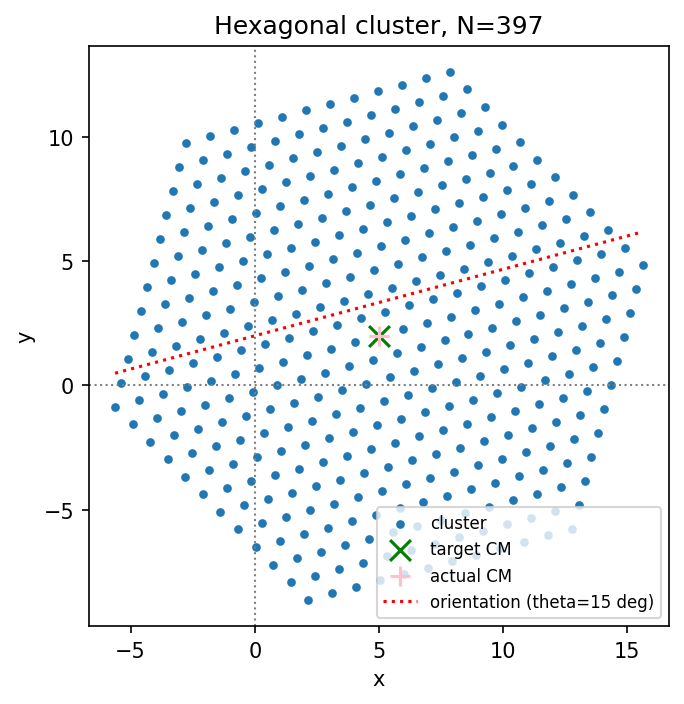

In [3]:
pos = make_cluster(a1, a2, N1, N2, shape='hexagon')
print('Hexagon: N=%d particles' % pos.shape[0])

tho  = 15.       # rotation angle [degrees]
X0, Y0 = 5., 2.  # target CM position

pos_shifted = rotate(pos, tho) + np.array([X0, Y0])

fig, ax = plt.subplots(dpi=150)
ax.scatter(pos_shifted[:,0], pos_shifted[:,1], s=10, label='cluster')
ax.scatter(X0, Y0, marker='x', color='green', s=100, label='target CM')
ax.scatter(*np.mean(pos_shifted, axis=0), marker='+',
           color='pink', s=100, label='actual CM')
xx = np.linspace(pos_shifted[:,0].min(), pos_shifted[:,0].max())
ax.plot(xx, Y0 + xx * tan(tho * pi/180.),
        lw=1.5, ls=':', color='red', label='orientation (theta=%.0f deg)' % tho)
ax.legend(fontsize=8)
ax.set_title('Hexagonal cluster, N=%d' % pos.shape[0])
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

### All shapes
  
  All available shapes on the same triangular lattice, with a two-atom honeycomb
  basis added. Adding a 2-atom basis doubles the number of particles per lattice site.
  
  Shape guide:
  - **circle**: isotropic; good default for finite-size scaling studies
  - **hexagon**: 6-fold symmetric; natural match for triangular lattice
  - **rectangle**: anisotropic contact; useful for directional friction studies
  - **triangle**: sharp edges; tests boundary effects
  - **parallelogram**: periodic-boundary compatible; exact tiling of the lattice (see Panizon Nanoscale 2023)
  - **ellipse**: semi-axes $r_x = N_1 |\mathbf{a}_1|$, $r_y = N_2 |\mathbf{a}_2|$



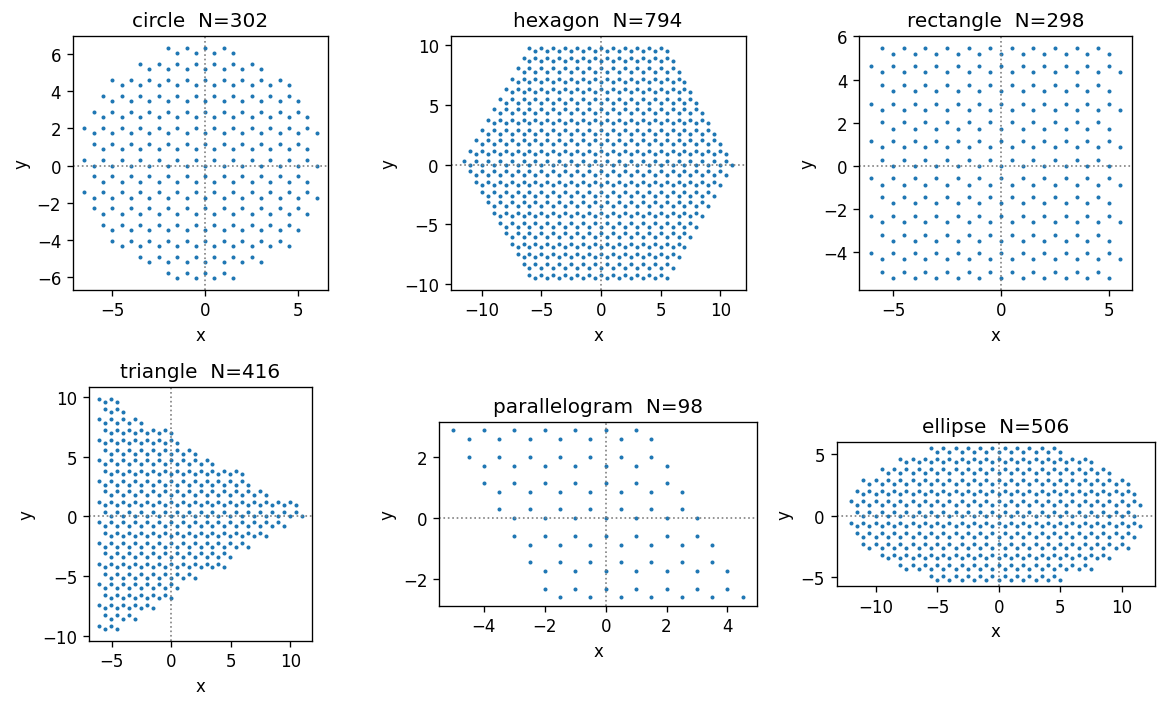

In [4]:
# Honeycomb basis: two atoms per unit cell.
# The second atom is displaced by (1/3)*a1 + (2/3)*a2 = [-1/6, 1/(2*sqrt(3))].
# The y-component 1/sqrt(3)/2 = 0.28867513...
cl_basis = [np.array([0., 0.]),
            np.array([-0.5, 1./(2.*sqrt(3.))])]   # = 0.28867513...

fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=120)
axes = axes.ravel()

for ax, shape in zip(axes, ['circle', 'hexagon', 'rectangle',
                              'triangle', 'parallelogram', 'ellipse']):
    # parallelogram requires sqrt(N1*N2) to be an odd integer
    n1, n2 = (7, 7) if shape == 'parallelogram' else (N1, N2)
    if shape == 'ellipse': n2 /= 2
    try:
        pos = make_cluster(a1, a2, n1, n2, shape=shape)
        pos = add_basis(pos, cl_basis)
        ax.scatter(pos[:,0], pos[:,1], s=2)
        ax.set_title('%s  N=%i' % (shape, pos.shape[0]))
    except Exception as e:
        ax.set_title('%s: %s' % (shape, e))
    plt_cosmetic(ax)

plt.tight_layout()
plt.show()

### Cluster from parameter dictionary
  
  `cluster_from_params` builds a cluster from a plain Python dict — the
  standard interface when loading a YAML input file (e.g. for the CLI).
  It always returns positions with CM at the origin and $\theta = 0$;
  shift and rotation are applied explicitly afterwards. 

Cluster circle, N=389


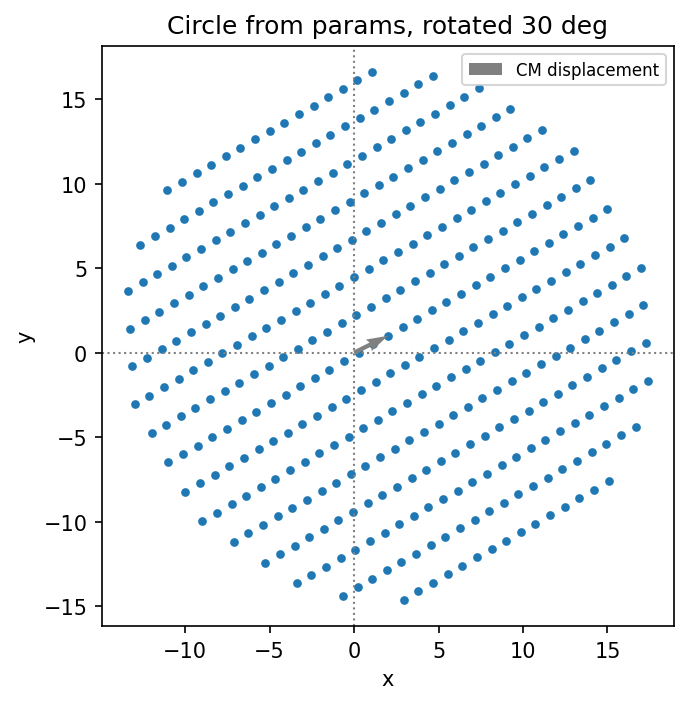

In [5]:
params = {
    'a1': [1., 0.], 'a2': [0., 2.],   # rectangular lattice
    'cl_basis': [[0., 0.]],
    'cluster_shape': 'circle',
    'N1': 20, 'N2': 20,
}

pos = cluster_from_params(params)
print('Cluster %s, N=%i' % (params['cluster_shape'], pos.shape[0]))

# Shift and rotate explicitly after creation.
theta, pos_cm = 30., np.array([2., 1.])
pos = rotate(pos, theta) + pos_cm

fig, ax = plt.subplots(dpi=150)
ax.scatter(pos[:,0], pos[:,1], s=10)
ax.quiver(0, 0, *pos_cm, angles='xy', scale_units='xy', scale=1,
          color='gray', label='CM displacement')
ax.set_title('Circle from params, rotated %.0f deg' % theta)
ax.legend(fontsize=8)
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

### Load from POSCAR
  
  To model real materials it is convenient to import geometry directly from
  ab-initio codes. `params_from_poscar` reads a
  [VASP POSCAR](https://www.vasp.at/wiki/index.php/POSCAR) file and returns
  a parameter dict (`a1`, `a2`, `cl_basis`) ready for `cluster_from_params`.
  
  Requirements for the POSCAR:
  - 2D periodicity encoded in the first two lattice vectors **a**, **b**
    (the third vector **c** must be along $z$)
  - All $z$-coordinates of the basis are projected away; use `cut_z` to select
    a specific layer in a multi-layer slab
    
  Requires: `pip install ase`


             a1: [1.2338620706831436, -2.137111795955346]
             a2: [1.2338620706831436, 2.137111795955346]
       cl_basis:
                 [0.0, 0.0]
                 [1.2338620706831438, -0.7123705986517821]
z coordinates of ignored atoms: [6.5137785 6.5137785]
Cluster hexagon, N=122


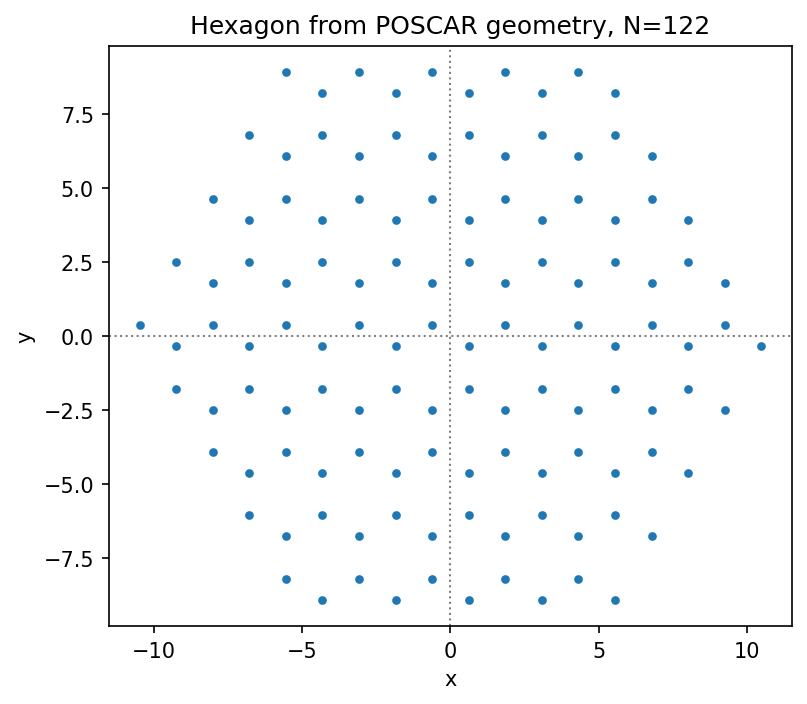

In [6]:
# params_from_poscar returns (poscar_params, z_coords_of_ignored_atoms).
# poscar_params contains a1, a2, cl_basis extracted from the file.
# Requires ASE: pip install ase
poscar_params, pos_z_ignored = params_from_poscar('./data/C.poscar', cut_z=6)

for k, v in poscar_params.items():
    if isinstance(v[0], list):
        print('%15s:' % k)
        for vv in v:
            print(' '*16, vv)
    else:
        print('%15s: %s' % (k, v))
print('z coordinates of ignored atoms:', pos_z_ignored)

# Combine the loaded lattice geometry with the desired macroscopic shape.
params = {**poscar_params,
          'cluster_shape': 'hexagon',
          'N1': 5, 'N2': 5}

pos = cluster_from_params(params)
print('Cluster %s, N=%i' % (params['cluster_shape'], pos.shape[0]))

fig, ax = plt.subplots(dpi=150)
ax.scatter(pos[:,0], pos[:,1], s=10)
ax.set_title('Hexagon from POSCAR geometry, N=%d' % pos.shape[0])
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

### Cluster from polygon shape
  
  To match an experimental cluster shape or test unusual geometries, define
  the cluster boundary as an arbitrary polygon.
  The [Shapely](https://github.com/shapely/shapely) package handles the
  point-in-polygon test.
  
  The polygon is defined by its vertices; any convex or concave shape works.

In [7]:
from shapely.geometry import Polygon
from shapely.plotting import patch_from_polygon

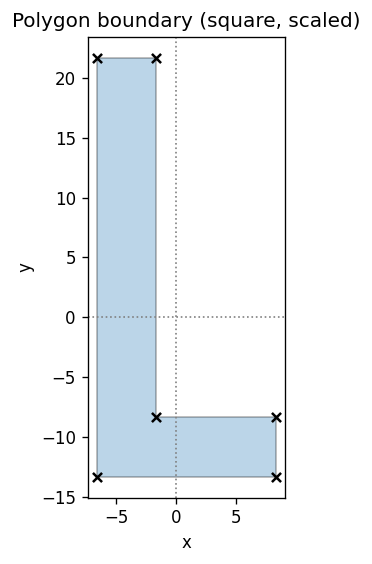

In [8]:
# Define the polygon boundary by its vertices.
# Uncomment the shape you want; only one should be active.

# --- Circle approximated as a 50-gon ---
# t = np.linspace(0, 1, 50, endpoint=False)
# poly_points = np.stack([np.cos(2*pi*t), np.sin(2*pi*t)], axis=1)

# --- Square ---
#poly_points = np.array([[-1.,-1.], [1.,-1.], [1.,1.], [-1.,1.]])

# --- L-shape ---
poly_points = np.array([[0.,0.], [3.,0.], [3.,1.],
                         [1.,1.], [1.,7.], [0.,7.]])

# Scale and centre.
poly_points = poly_points * 5.
poly_points -= np.mean(poly_points, axis=0)

poly = Polygon(poly_points)

fig, ax = plt.subplots(dpi=120)
patch = patch_from_polygon(poly, facecolor='tab:blue', alpha=0.3)
ax.add_patch(patch)
ax.scatter(poly_points[:,0], poly_points[:,1], c='k', marker='x', s=30)
ax.set_title('Polygon boundary (square, scaled)')
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

#### Mask lattice with polygon
  
  `cluster_poly` generates a lattice inside the bounding box of the polygon,
  then keeps only the points inside it (`direction=0`) or outside it
  (`direction=1`, for cutting holes).
  
  The key feature is that the polygon and the lattice can be rotated
  **independently** — this is how you create clusters with a deliberate
  mismatch between the crystal symmetry axis and the boundary shape.

N=258, CM=[-2.62851167 -0.126039  ]


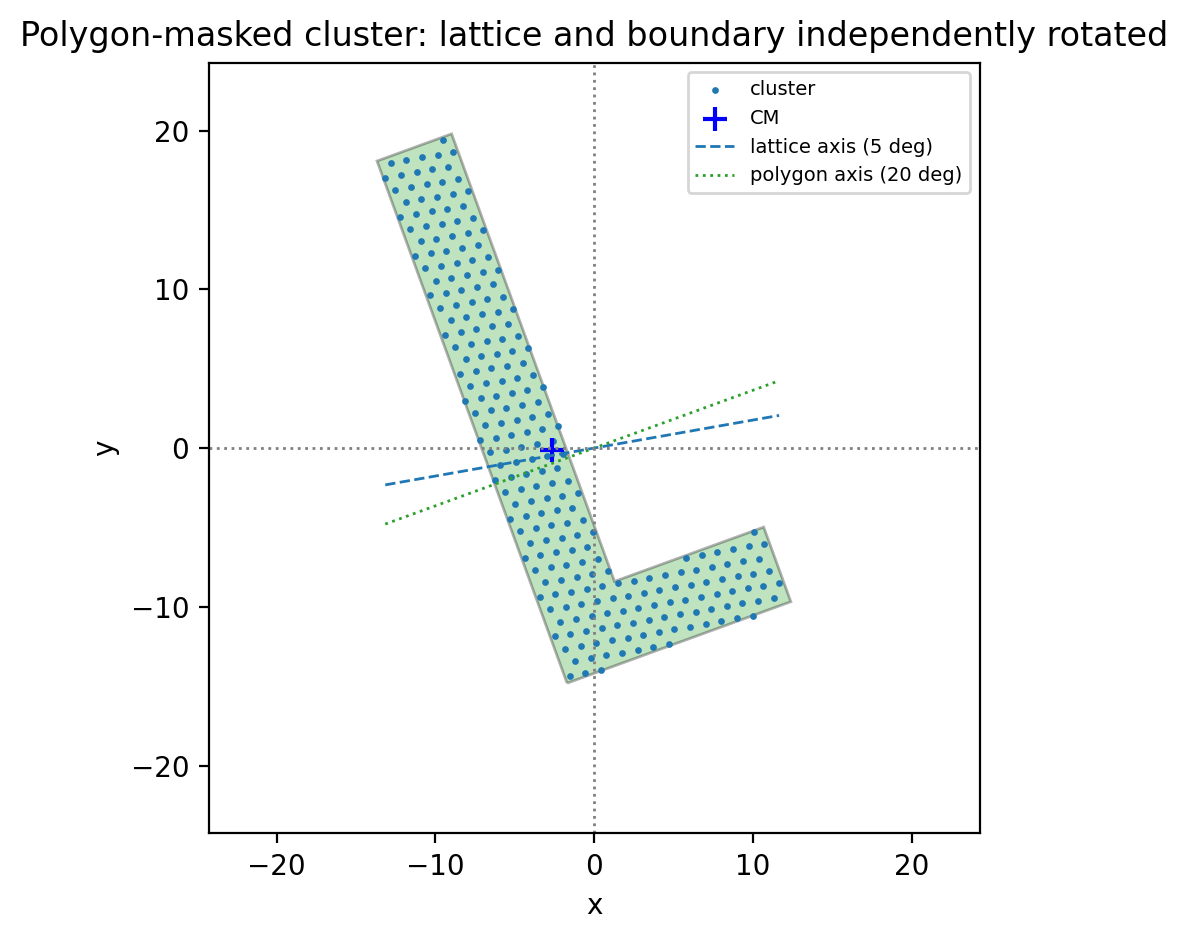

In [9]:
# Polygon rotation is independent of the lattice orientation.
tho = 20.   # polygon rotation [degrees]

poly_rotated = get_poly(poly_points, tho=tho, shift=[0., 0.], cm=False, scale=1)


a1, a2 = [1., 0.], [-0.5, sqrt(3.)/2.]
thl = 10 # lattice orientation [degrees] -- independent of polygon
a1, a2 = rotate(a1, thl), rotate(a2, thl)

params = {
    'a1': a1, 'a2': a2,
    'cl_basis': [[0., 0.]],
    'N1': 20, 'N2': 20,
    'theta': 5,   # flake rotation [degrees] -- independent of polygon and lattice ! not applied at construction !
}

# direction=0: keep lattice points inside polygon
pos = cluster_poly(poly_rotated, params, direction=0)
#pos -= np.mean(pos, axis=0)   # re-centre CM
print('N=%i, CM=%s' % (pos.shape[0], np.mean(pos, axis=0)))

fig, ax = plt.subplots(dpi=200)
ax.add_patch(patch_from_polygon(poly_rotated,
             facecolor='tab:green', alpha=0.3, zorder=0))
ax.scatter(pos[:,0], pos[:,1], s=2, label='cluster')
ax.scatter(*np.mean(pos, axis=0), marker='+', c='blue', s=80, label='CM')

xx = np.linspace(pos[:,0].min(), pos[:,0].max())
ax.plot(xx, xx*tan(thl*pi/180.),
        ls='--', lw=1, color='tab:blue', label='lattice axis (%.0f deg)' % params['theta'])
ax.plot(xx, xx*tan(tho*pi/180.),
        ls=':', lw=1, color='tab:green', label='polygon axis (%.0f deg)' % tho)

side = 1.1 * np.max(np.linalg.norm(pos, axis=1))
ax.set_xlim([-side, side])
ax.set_ylim([-side, side])
ax.legend(fontsize=7)
ax.set_title('Polygon-masked cluster: lattice and boundary independently rotated')
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

#### Polygon from params (with hole)
  
  `cluster_from_params` with `cluster_shape='polygon'` and `masked_shape`
  lets you punch a polygon hole into a base shape.
  Set `direction=1` to remove points *inside* the polygon rather than keeping them.



N=4700


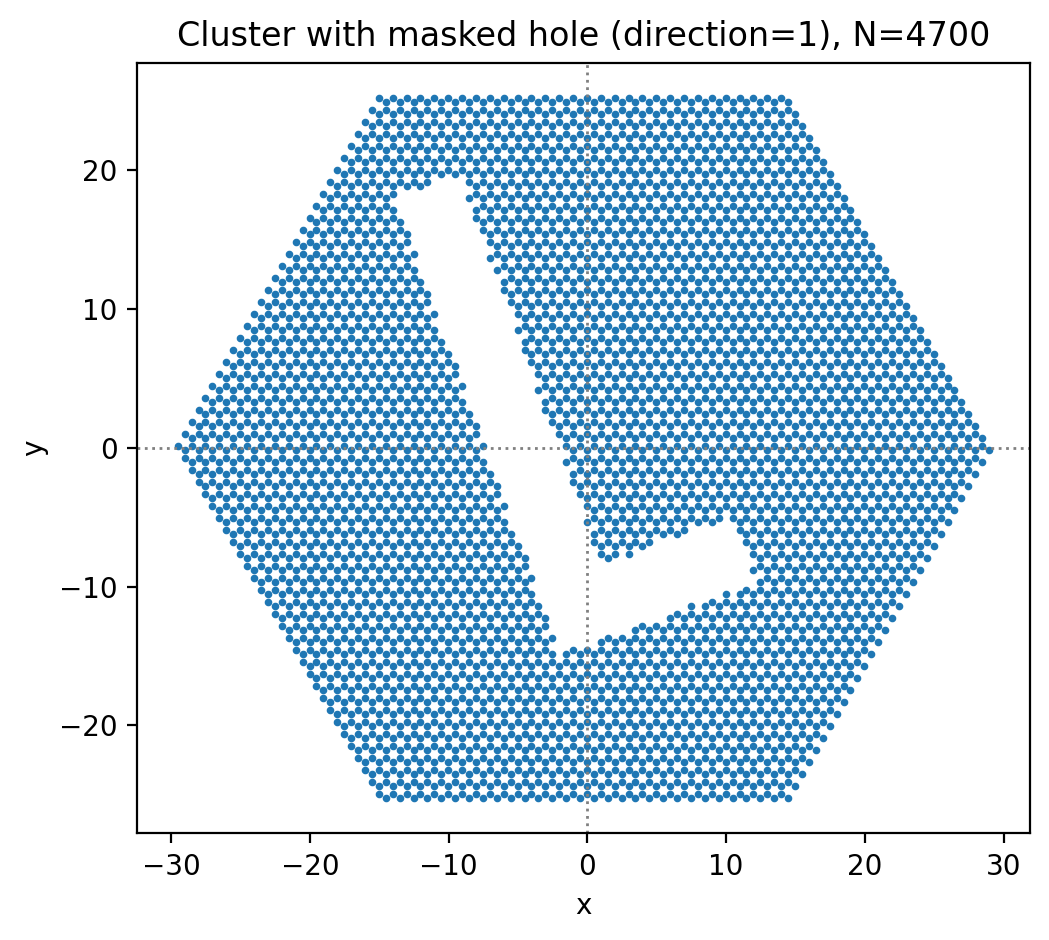

In [10]:
# Punch the square polygon as a hole into a hexagonal cluster.
params_hole = {
    'a1': [1., 0.], 'a2': [-0.5, sqrt(3.)/2.],
    'cl_basis': [[0., 0.], [-0.5, 1./(2.*sqrt(3.))]],  # honeycomb basis
    'cl_poly':  np.array(poly_rotated.exterior.coords.xy).T,
    'cluster_shape': 'polygon',
    'masked_shape':  'hexagon',   # base shape to punch the hole into
    'direction': 1,               # 1 = remove points inside polygon
    'N1': 30, 'N2': 30,
    'theta': 0,                  # flake rotation [degrees]
}

pos = cluster_from_params(params_hole)
pos -= np.mean(pos, axis=0)
print('N=%i' % pos.shape[0])

fig, ax = plt.subplots(dpi=200)
ax.scatter(pos[:,0], pos[:,1], s=3)
ax.set_title('Cluster with masked hole (direction=1), N=%d' % pos.shape[0])
plt_cosmetic(ax)
plt.tight_layout()
plt.show()